**14/08/2026** -- Supplementary figure S2: Evaluation of model-predicted fire PM2.5 concentrations against Hu et al. (2025) estimates across 12 cross-validation folds.

Using 2000-2023 Hu et al. data.

In [5]:
library(dplyr)
library(readr)
library(stringr)
library(purrr)
library(ggplot2)
library(scales)

In [2]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))

In [3]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, "data/spatial/transported_pm_inla/kfold_cv_results")

In [6]:
data <- list.files(DATA_PATH, pattern = "\\.csv$", full.names = TRUE) |>
    map_dfr(\(file) {
        # Extract the fold no. from the file name (`preds_fold_X.csv`)
        fold <- str_extract(basename(file), "(?<=fold_)\\d+") |> as.integer()
        # Read and append fold col
        read_csv(file) |>
            mutate(fold = fold)
    })

Rows: 1491480 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): year, observed, predicted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1491480 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): year, observed, predicted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1491480 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): year, observed, predicted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1491480 Columns: 3
── Column specification ──────────────────

In [ ]:
# Add 'years' label by fold
data <- data |> 
    group_by(fold) |> 
    mutate(
        years = paste0(min(year), "-", max(year))
    ) |> 
    ungroup()

In [11]:
data |> head()

year,observed,predicted,fold,years
<dbl>,<dbl>,<dbl>,<int>,<chr>
2000,0.2602426,0.4505702,1,2000-2002
2000,0.1681909,0.7760562,1,2000-2002
2000,0.4688610,0.5904677,1,2000-2002
2000,0.3699755,0.2549744,1,2000-2002
2000,0.3548410,0.3799887,1,2000-2002
2000,0.1861900,0.5221129,1,2000-2002


In [14]:
# Summary of predictive performance by fold
summary_by_fold <- data |> 
    group_by(years) |> 
    summarise(
        r2      = cor(observed, predicted, use = "complete.obs")**2,
        rmse    = sqrt(mean((observed - predicted)^2, na.rm = TRUE)),
        mae     = mean(abs(observed - predicted), na.rm = TRUE),
        .groups = "drop"
    )
summary_by_fold

years,r2,rmse,mae
<chr>,<dbl>,<dbl>,<dbl>
2000-2002,0.8588516,2.397939,1.345260
2003-2005,0.8843431,2.427723,1.318870
2006-2008,0.8615963,2.867340,1.421853
2009-2011,0.8704368,2.576250,1.340110
2012-2014,0.8715650,2.364965,1.246213
2015-2017,0.8306125,2.576292,1.425989
2018-2020,0.8293770,2.542802,1.482319
2021-2023,0.7040797,4.319493,1.887840


In [16]:
# Mean metrics
mean_r2   <- mean(summary_by_fold$r2)
mean_rmse <- mean(summary_by_fold$rmse)
mean_mae  <- mean(summary_by_fold$mae)

cat("Mean R2  :", round(mean_r2, 2), "\n")
cat("Range R2 :", round(min(summary_by_fold$r2), 2), "-", round(max(summary_by_fold$r2), 2), "\n") #nolint
cat("Mean RMSE:", round(mean_rmse, 3), "\n")
cat("Mean MAE :", round(mean_mae, 3), "\n")

Mean R2  : 0.84 
Range R2 : 0.7 - 0.88 
Mean RMSE: 2.759 
Mean MAE : 1.434 


In [17]:
# Custom ggplot theme
nice_theme <- function() {
    theme_minimal() +
    theme(
        legend.position = "inside",
        legend.position.inside = c(0.86, 0.08),
        legend.direction = "horizontal",
        legend.title.position = "top",

        axis.line = element_line(color = "black"),
        axis.ticks = element_line(color = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),

        # axis.title = element_text(color = "black", size = 14),
        axis.title.y = element_text(color = "black", size = 14, margin = margin(r = 20)),
        axis.title.x = element_text(color = "black", size = 14, margin = margin(t = 20)),
        axis.text = element_text(color = "black", size = 12),

        legend.title = element_text(color = "black", size = 14),
        legend.text = element_text(color = "black", size = 12),
        
        # strip.text = element_text(color = "black", size = 14, hjust = 0)
        strip.text = element_blank(),
        strip.background = element_blank()
    )
}

`geom_smooth()` using formula = 'y ~ x'


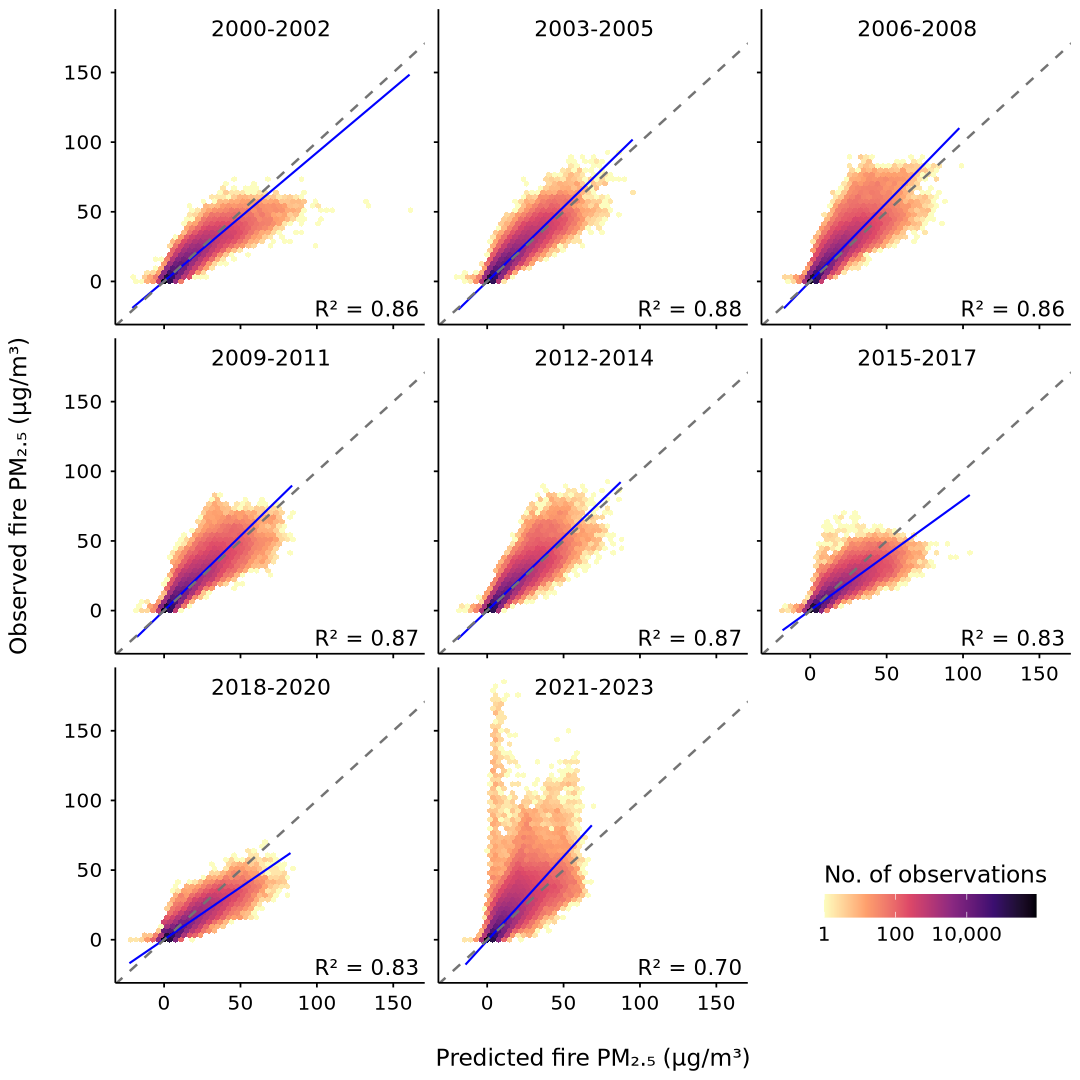

In [19]:
# Facet hexbin scatterplot by fold
options(repr.plot.height = 9, repr.plot.width = 9)

ggplot(
    data,
    aes(x = predicted, y = observed)
) +
    geom_hex(
        bins = 50,
        aes(fill = after_stat(count)),
        color = NA
    ) +
    geom_smooth(
        method = "lm",
        se = FALSE,
        color = "blue",
        linewidth = 0.6
    ) +
    geom_abline(
        intercept = 0,
        slope = 1,
        color = "gray45",
        linetype = "dashed",
        linewidth = 0.7
    ) +
    scale_fill_viridis_c(
        option = "A",
        trans = "log10",
        name = "No. of observations",
        direction = -1,
        labels = comma,
        guide = guide_colorbar(
            direction = "horizontal",
            title.position = "top",
            title.hjust = 0,
            barwidth = unit(4.5, "cm"),
            barheight = unit(0.5, "cm")
        )
    ) +
    facet_wrap(~ years, axes = "all", axis.labels = "margins") +
    geom_text(
        data = data %>%
            distinct(years),
        aes(
            x = 70, # 75ug/m3 is roughly the centre
            y = Inf,
            label = years
        ),
        hjust = 0.5,
        vjust = 1.7,
        color = "black",
        size = 4.6,
        fontface = "plain",
        inherit.aes = FALSE
    ) +
    geom_text(
        data = summary_by_fold %>%
            select(years, r2, rmse) %>%
            distinct(),
        aes(
            x = Inf,
            y = -Inf,
            # label = sprintf("R² = %.2f\nRMSE = %.2f", r2, rmse)
            label = sprintf("R² = %.2f", r2)
        ),
        hjust = 1.05,
        vjust = -0.5,
        color = "black",
        size = 4.5,
        inherit.aes = FALSE
    ) +
    labs(
        y = "Observed fire PM₂.₅ (μg/m³)",
        x = "Predicted fire PM₂.₅ (μg/m³)"
    ) +
    nice_theme()

In [76]:
ggsave(
    filename = file.path(root, "paper_results/figures/supplementary_fig_S2.png"),
    width = 9,
    height = 9,
    dpi = 450,
    device = grDevices::png()
)

`geom_smooth()` using formula = 'y ~ x'


In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/inla/share/proj")

In [2]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(dtplyr)
    library(reshape2)
    library(sf)
    library(spdep)
    library(INLA)
    library(purrr)
    library(tibble)
    library(scales)
    library(ggplot2)
    library(patchwork)
    library(cowplot)
})

In [3]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/transported_pm_inla/data_prep.R"))

In [ ]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "transported_GFED_emissions_incl_global_2000_2023")
ADJ_PATH    <- file.path(SCRATCH_DIR, 
                         "data/spatial/transported_pm_inla/afr.adj")

In [6]:
# Load data
data    <- load_data_and_wrangle(
    filepath    = DATA_PATH,
    years_sel   = 2018:2023 #2000:2023 (see .R script for full 2000-2023)
)

Read year: 2018

Read year: 2019

Read year: 2020

Read year: 2021

Read year: 2022

Read year: 2023

Xu grid cells: 41430

Total rows before filtering: 2984064

Total rows after filtering to Xu grid: 2982960



#### 1. Define model

In [7]:
# --- Priors -------------------------------------------------------------------
hyper_bym2 <- list(
    # Marginal variance of the BYM2 spatial effect:
    # P(1 / sqrt(tau) > 50 / 0.31) = 0.01
    # -> implies an approximate marginal spatial SD of 50 with probability 0.01
    # -> penalises only implausibly large spatial effects
    prec = list(prior = "pc.prec", param = c(50 / 0.31, 0.01)),
    
    # Mixing parameter:
    # A priori, 50% probability that more than half of the spatial variance
    # is attributed to the structured spatial effect.
    phi  = list(prior = "pc", param = c(0.5, 0.5))
)

# Observation / residual variance:
# P(SD_residual > 50) = 0.01
hyper_sigma <- list(
    hyper = list(
        prec = list(prior = "pc.prec", param = c(50, 0.01))
    )
)

# --- Model -------------------------------------------------------------------
formula <- fire_PM25_hu ~
    emis_0_20km + emis_20_100km + emis_100_200km + emis_200_350km +
    emis_350_500km + emis_500_750km + emis_750_1000km +
    emis_1000_1500km + emis_1500_2000km +
    u10 + v10 + d2m + t2m + sp + tp +
    f(grid_id, model = "bym2", graph = ADJ_PATH, scale.model = TRUE,
      hyper = hyper_bym2)

#### 2. K-fold CV loop
INLA out-of-sample predictions are made by fitting a model to observations with `NA` in response variable.

In [14]:
# Create 2-year folds
years <- sort(unique(data$year))
folds <- split(years, ceiling(seq_along(years) / 2))

In [15]:
folds

$`1`
[1] 2018 2019

$`2`
[1] 2020 2021

$`3`
[1] 2022 2023

In [16]:
folds <- folds[c(2,3)]

In [17]:
folds

$`2`
[1] 2020 2021

$`3`
[1] 2022 2023

In [18]:
# Variables to scale
emis_vars  <- grep("^emis.*km$", names(data), value = TRUE)
met_vars   <- c("u10", "v10", "d2m", "t2m", "sp", "tp")
scale_vars <- c(emis_vars, met_vars)

# Func to scale using mean/sd of train data
scale_train_test <- function(train, test, vars) {

    for (v in vars) {

        m   <- mean(train[[v]], na.rm = TRUE)
        sdv <- sd(train[[v]], na.rm = TRUE)

        train[[v]] <- (train[[v]] - m) / sdv
        test[[v]]  <- (test[[v]]  - m) / sdv
    }

    list(train = train, test = test)
}

In [19]:
# Objects to store results etc.
results_list <- list()
r2_values    <- numeric(length(folds))
rmse_values  <- numeric(length(folds))
mae_values   <- numeric(length(folds))

previous_mode <- NULL

In [20]:
# ==============================================================================
# Cross-validation loop
# ==============================================================================
for (i in seq_along(folds)) {

    message("Running fold ", i, " / ", length(folds))

    test_years <- folds[[i]]

    train_data <- data %>% filter(!year %in% test_years)
    test_data  <- data %>% filter(year %in% test_years)

    # ---- Scale using training mean & sd ----
    scaled <- scale_train_test(train_data, test_data, scale_vars)
    train_data <- scaled$train
    test_data  <- scaled$test

    # ---- Combine back together ----
    fold_data <- bind_rows(train_data, test_data)

    # ---- Set test response to NA (to make INLA OOS preds) ----
    fold_data$fire_PM25_hu[fold_data$year %in% test_years] <- NA

    # ---- Fit INLA ----
    message("  Fitting INLA model...")
    if (is.null(previous_mode)) {
        fit <- inla(
            formula,
            data                = fold_data,
            family              = "gaussian",
            control.family      = hyper_sigma,
            control.predictor   = list(compute = TRUE),
            control.compute     = list(dic = FALSE, waic = FALSE),
            verbose             = FALSE
        )
    } else {
        fit <- inla(
            formula,
            data                = fold_data,
            family              = "gaussian",
            control.family      = hyper_sigma,
            control.predictor   = list(compute = TRUE),
            control.compute     = list(dic = FALSE, waic = FALSE),
            control.mode        = list(theta = previous_mode, restart = TRUE),
            verbose             = FALSE
        )
    }

    message("  Model fit complete.")

    previous_mode <- fit$mode$theta

    # ---- Extract predictions (posterior means) ----
    preds <- fit$summary.fitted.values$mean

    test_index <- which(fold_data$year %in% test_years)

    # Observed values from the held-out test data
    obs <- test_data$fire_PM25_hu

    # INLA predictions for the held-out rows
    pred <- preds[test_index]

    # ---- Metrics ----
    r2_values[i]   <- cor(obs, pred, use = "complete.obs")^2
    rmse_values[i] <- sqrt(mean((obs - pred)^2, na.rm = TRUE))
    mae_values[i]  <- mean(abs(obs - pred), na.rm = TRUE)

    results_list[[i]] <- data.frame(
        observed  = obs,
        predicted = pred,
        fold      = i
    )
}

Running fold 1 / 2

  Fitting INLA model...

  Model fit complete.

Running fold 2 / 2

  Fitting INLA model...

  Model fit complete.



In [21]:
# ==============================================================================
# Combine results
# ==============================================================================
cv_results <- bind_rows(results_list)

mean_r2   <- mean(r2_values)
mean_rmse <- mean(rmse_values)
mean_mae  <- mean(mae_values)

cat("Mean R2  :", round(mean_r2, 2), "\n")
cat("Range R2 :", round(min(r2_values), 2), "-", round(max(r2_values), 2), "\n") #nolint
cat("Mean RMSE:", round(mean_rmse, 3), "\n")
cat("Mean MAE :", round(mean_mae, 3), "\n")

Mean R2  : 0.74 
Range R2 : 0.69 - 0.78 
Mean RMSE: 3.872 
Mean MAE : 1.702 


In [22]:
r2_values

[1] 0.7823435 0.6944702

#### 3. Plot results

In [23]:
# Build tidy dataframe of preds for facet plot
preds_list <- list()

for (i in seq_along(results_list)) {

    fold_res <- results_list[[i]]
    test_years <- folds[[i]]

    year_label <- paste0(min(test_years), "-", max(test_years))

    fold_df <- fold_res %>%
        mutate(
            fire_PM25  = observed,
            .pred      = predicted,
            years      = year_label,
            r2         = r2_values[i],
            rmse       = rmse_values[i]
        )

    preds_list[[i]] <- fold_df
}

preds <- bind_rows(preds_list)

In [24]:
# Custom ggplot theme
nice_theme <- function() {
    theme_minimal() +
    theme(
        legend.position = "bottom",
        # panel.border = element_rect(color = "black", fill = NA, linewidth = 1),  # black border
        axis.line = element_line(color = "black"),
        axis.ticks = element_line(color = "black"),                       # black ticks
        panel.grid.major = element_blank(),                               # no major gridlines
        panel.grid.minor = element_blank(),                                # no minor gridlines
        axis.title = element_text(color = "black"),
        axis.text = element_text(color = "black"),
        legend.title = element_text(color = "black"),
        legend.text = element_text(color = "black"),
        strip.text = element_text(color = "black", margin = margin(t = 100)),   # facet labels
        plot.title = element_text(color = "black")
    )
}

`geom_smooth()` using formula = 'y ~ x'


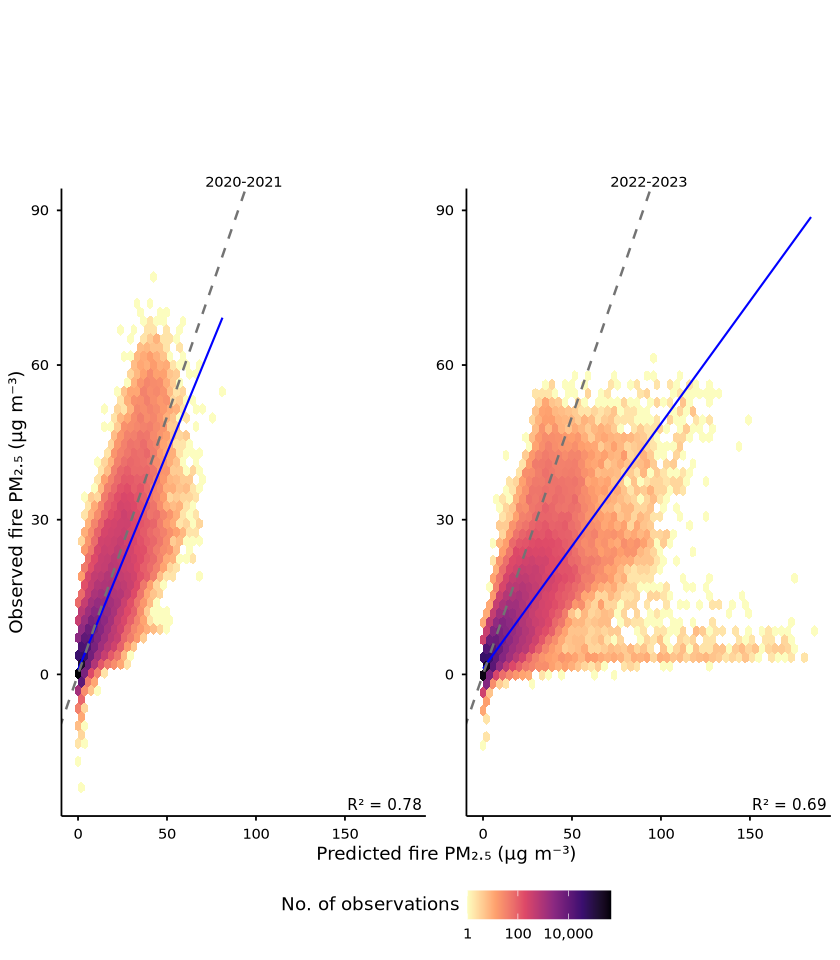

In [25]:
# Facet hexbin scatterplot by fold
options(repr.plot.height = 8, repr.plot.width = 7)

ggplot(
    preds,
    aes(x = fire_PM25, y = .pred)
) +
    geom_hex(
        bins = 50,
        aes(fill = after_stat(count)),
        color = NA
    ) +
    geom_smooth(
        method = "lm",
        se = FALSE,
        color = "blue",
        linewidth = 0.6
    ) +
    geom_abline(
        intercept = 0,
        slope = 1,
        color = "gray45",
        linetype = "dashed",
        linewidth = 0.7
    ) +
    scale_fill_viridis_c(
        option = "A",
        trans = "log10",
        name = "No. of observations",
        direction = -1,
        labels = comma
    ) +
    facet_wrap(~ years, axes = "all") +
    geom_text(
        data = preds %>%
            select(years, r2, rmse) %>%
            distinct(),
        aes(
            x = Inf,
            y = -Inf,
            # label = sprintf("R² = %.2f\nRMSE = %.2f", r2, rmse)
            label = sprintf("R² = %.2f", r2)
        ),
        hjust = 1.05,
        vjust = -0.5,
        color = "black",
        size = 3.2,
        inherit.aes = FALSE
    ) +
    labs(
        y = "Observed fire PM₂.₅ (μg m⁻³)",
        x = "Predicted fire PM₂.₅ (μg m⁻³)"
    ) +
    nice_theme() +
    theme(
        legend.title = element_text(
            margin = margin(b = 15, r = 5),
            color = "black"
        )
    )

In [26]:
ggsave(
    filename = file.path(root, "paper_results/figures/supplementary_fig_S2.png"),
    width = 7,
    height = 8,
    dpi = 450,
    device = grDevices::png()
)

Warning message:
“Removed 1988928 rows containing non-finite outside the scale range
(`stat_binhex()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1988928 rows containing non-finite outside the scale range
(`stat_smooth()`).”


In [70]:
data |> head()

V1,lon,lat,total_PM25,total_O3,fire_PM25,fire_O3,month,year,fire_PM25_hu,⋯,emis_1500_2000km_Western Asia,emis_1500_2000km_Western Europe,grid_id,emis_0_20km,emis_20_100km,emis_20_100km_Western Africa,emis_20_100km_Northern Africa,emis_20_100km_Central Africa,emis_20_100km_Southern Africa,emis_20_100km_Eastern Africa
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<dbl>,⋯,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,-25.25,17,26.91786,80.90209,0.01200753,1.0162082,0,2018,0.01360096,⋯,0,0,1,0,0,0,0,0,0,0
41430,-25.25,17,15.52543,85.21772,0.16108638,1.1788369,1,2018,0.19692734,⋯,0,0,1,0,0,0,0,0,0,0
82860,-25.25,17,15.67921,80.62009,0.09626792,1.0263285,2,2018,0.14817576,⋯,0,0,1,0,0,0,0,0,0,0
124290,-25.25,17,14.14901,86.53136,0.35797064,1.0559404,3,2018,0.52670175,⋯,0,0,1,0,0,0,0,0,0,0
165720,-25.25,17,11.25264,85.66238,0.76019714,1.3557882,4,2018,1.13425590,⋯,0,0,1,0,0,0,0,0,0,0
207150,-25.25,17,12.84027,68.82244,0.33939951,0.8521048,5,2018,0.68405690,⋯,0,0,1,0,0,0,0,0,0,0


In [72]:
mod = stats::lm(
    formula = fire_PM25_hu ~ emis_0_20km + emis_20_100km + emis_100_200km + 
                emis_200_350km + emis_350_500km + emis_500_750km + emis_750_1000km + 
                emis_1000_1500km + emis_1500_2000km + u10 + v10 + d2m + t2m + 
                sp + tp,
    data = data |> filter(year %in% 2018:2019)
)

In [73]:
mod |> summary()


Call:
stats::lm(formula = fire_PM25_hu ~ emis_0_20km + emis_20_100km + 
    emis_100_200km + emis_200_350km + emis_350_500km + emis_500_750km + 
    emis_750_1000km + emis_1000_1500km + emis_1500_2000km + u10 + 
    v10 + d2m + t2m + sp + tp, data = filter(data, year %in% 
    2018:2019))

Residuals:
    Min      1Q  Median      3Q     Max 
-31.569  -0.938  -0.391   0.527  35.003 

Coefficients:
                   Estimate Std. Error  t value Pr(>|t|)    
(Intercept)      -1.239e+01  1.206e-01 -102.733  < 2e-16 ***
emis_0_20km       2.137e+00  1.809e-02  118.134  < 2e-16 ***
emis_20_100km     3.819e-01  2.864e-03  133.326  < 2e-16 ***
emis_100_200km    1.309e-01  1.133e-03  115.583  < 2e-16 ***
emis_200_350km    6.672e-02  5.048e-04  132.167  < 2e-16 ***
emis_350_500km    2.728e-02  3.619e-04   75.389  < 2e-16 ***
emis_500_750km    2.253e-02  1.582e-04  142.412  < 2e-16 ***
emis_750_1000km   1.527e-02  1.093e-04  139.783  < 2e-16 ***
emis_1000_1500km  1.040e-02  3.908e-05  266.201  < 

In [102]:
data_oos = data |> filter(year %in% 2022)
oos = stats::predict(
    mod,
    newdata = data_oos,
    type = "response"
)

In [103]:
oos = unname(oos)

In [104]:
cor(oos, data_oos$fire_PM25_hu)**2

[1] 0.6270319

`geom_smooth()` using formula = 'y ~ x'


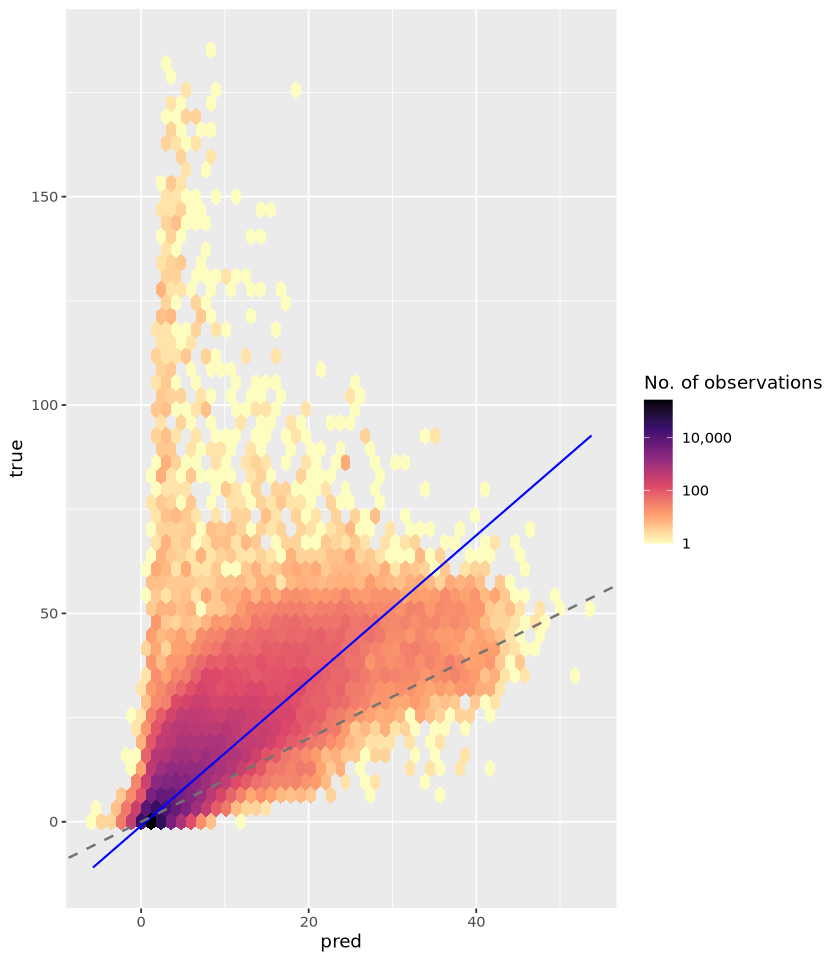

In [105]:
ggplot(
    data = tibble(
        true = data_oos$fire_PM25_hu,
        pred = oos
    ),
    aes(y = true, x = pred)
) +
    geom_hex(
        bins = 50,
        aes(fill = after_stat(count)),
        color = NA
    ) +
    geom_smooth(
        method = "lm",
        se = FALSE,
        color = "blue",
        linewidth = 0.6
    ) +
    geom_abline(
        intercept = 0,
        slope = 1,
        color = "gray45",
        linetype = "dashed",
        linewidth = 0.7
    ) +
    scale_fill_viridis_c(
        option = "A",
        trans = "log10",
        name = "No. of observations",
        direction = -1,
        labels = comma
    )

In [106]:
str(oos)

 num [1:497160] 1.176 0.976 0.73 0.835 0.89 ...


In [28]:
formula

fire_PM25_hu ~ emis_0_20km + emis_20_100km + emis_100_200km + 
    emis_200_350km + emis_350_500km + emis_500_750km + emis_750_1000km + 
    emis_1000_1500km + emis_1500_2000km + u10 + v10 + d2m + t2m + 
    sp + tp + f(grid_id, model = "bym2", graph = ADJ_PATH, scale.model = TRUE, 
    hyper = hyper_bym2)